# Banco de Dados II — Polymarket no BigQuery
## Debate Biden × Trump (27/06/2024) e a reação do mercado *"Biden drops out"*

**Trainee:** `Júlia Vilela`
**Mercado:** Biden drops out (market_id `252294`) · **Outcome analisado:** YES (`asset_id ...404468`)
**Período:** 24/06/2024 – 24/07/2024

> **Reprodução.** As consultas rodaram no BigQuery a partir do meu projeto pessoal (Sandbox), lendo de
> `even-continuity-441808-j0`. Os resultados foram exportados como CSV para `dados/` (link do Drive no
> `README.md`). Este notebook lê **apenas** de `dados/` — baixe os CSVs do Drive para essa pasta antes
> de executar. Nenhuma tabela foi materializada no projeto de treino (Sandbox, sem escrita); cada
> consulta é um `WITH ... SELECT` exportado.

## 0. Setup

In [7]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
pd.set_option("display.max_columns", None)

DEBATE   = pd.Timestamp("2024-06-28 01:00:00")  # 27/06 21h ET = 28/06 01h UTC
WITHDRAW = pd.Timestamp("2024-07-21 00:00:00")  # anúncio da desistência
MARKET_ID    = "252294"
ASSET_ID_YES = "80466862227762400456474037114326989569691448086113369690204721936360568404468" 

## 1. Evento, pergunta de pesquisa e hipótese inicial

**Evento externo.** Em 27/06/2024 (21h ET) ocorreu o primeiro debate presidencial Biden × Trump. O
desempenho de Biden desencadeou pressão que culminou, em 21/07/2024, no anúncio de sua saída da disputa.
O mercado analisado precifica exatamente essa probabilidade.

**Pergunta central.** O mercado precificou a saída de forma gradual após o debate, ou reagiu de
forma concentrada em poucos momentos (o debate e o anúncio)? O volume anômalo antecede ou
acompanha os movimentos de preço?

**Hipótese inicial.** O debate provoca salto imediato de probabilidade; segue-se deriva ascendente com
volume elevado; o anúncio de 21/07 é o maior choque de volume, com pouco movimento de preço restante.

**Refutação.** Enfraquecida se não houver anomalia de volume perto dos eventos, ou se o preço se mover
sem volume associado.

**Outcome.** O mercado é binário (YES/NO). Confirmei pela trajetória de preço que o token **YES**
(`...404468`) sobe de ~0,19 (fim de junho) a ~0,94 (21/07). Todas as features de preço usam esse token.

## 2. Exploração inicial

Estratégia de custo: comecei pelo mart diário (megabytes) e só depois desci para `trades`, sempre com
filtro de partição (`DATE(trade_timestamp)`) e de cluster (`market_id`).

### 2.1 Mercado escolhido

In [13]:
SQL_MERCADO = r"""
SELECT market_id, question, event_title, volume, created_at, end_date, closed
FROM `even-continuity-441808-j0.polymarket_optimized.markets`
WHERE LOWER(question) LIKE '%biden%'
  AND (LOWER(question) LIKE '%drop%' OR LOWER(question) LIKE '%withdraw%'
       OR LOWER(question) LIKE '%step%' OR LOWER(question) LIKE '%nominee%')
ORDER BY volume DESC;
"""
mercados = pd.read_csv("dados/01_exploracao_mercados.csv")
mercados.head()

,market_id,question,event_title,volume,end_date,closed
0,252294,Biden drops out of presidential race?,Biden drops out of presidential race?,2.112239e+07,2024-11-04 12:00:00.000000 UTC,1
1,502223,Biden drops out by July 4?,Biden drops out by July 4?,4.490152e+06,2024-07-04 12:00:00.000000 UTC,1
2,503131,Biden drops out by July 12?,Biden drops out by July 12?,2.139767e+06,2024-07-12 12:00:00.000000 UTC,1
3,503254,Biden drops out in July?,Biden drops out in July?,2.092273e+06,2024-07-31 12:00:00.000000 UTC,1
4,503182,Will Joe Biden be the 2024 Democratic VP nominee?,Democratic VP nominee?,1.726224e+06,2024-08-22 12:00:00.000000 UTC,1


A busca por mercados relacionados à saída de Biden retornou 70 resultados, revelando que o tema foi um dos mais negociados do Polymarket em 2024. Selecionei o market_id 252294 ("Biden drops out of presidential race?") com base nos critérios de 
- liquidez: possui uma densidade que garante trades em praticamente todas as horas da janela e viabiliza features horárias sem lacunas relevantes
- cobertura temporal: o mercado permaneceu aberto e líquido durante todo o período crítico — antes do debate (27/06), durante a fase de pressão política e no anúncio de 21/07. Isso permite observar a desistência como um movimento de probabilidade dentro de um mercado ativo, e não como um simples fechamento.


### 2.2 Identificação do outcome YES

Trajetória diária de preço por `asset_id`. A checagem de sanidade é a complementaridade YES+NO ≈ 1.

In [11]:
SQL_OUTCOMES = r"""
SELECT DATE(trade_timestamp) AS dia, asset_id,
       ROUND(SAFE_DIVIDE(SUM(price*usd_amount), SUM(usd_amount)),3) AS vwap_dia,
       ROUND(SUM(usd_amount),0) AS volume_usd
FROM `even-continuity-441808-j0.polymarket_optimized.trades`
WHERE market_id = '252294'
  AND DATE(trade_timestamp) BETWEEN '2024-06-24' AND '2024-07-24'
GROUP BY dia, asset_id ORDER BY asset_id, dia;
"""
traj = pd.read_csv("dados/01b_trajetoria_outcomes.csv", parse_dates=["dia"])
piv = traj.pivot_table(index="dia", columns="asset_id", values="vwap_dia")
piv["soma_YES_NO"] = piv.sum(axis=1)
piv.tail(5)

asset_id,55053017623018167103206225381535351479731721326578895660347356086269854794785,80466862227762400456474037114326989569691448086113369690204721936360568404468,soma_YES_NO
dia,,,
2024-07-17,0.557,0.522,1.079
2024-07-18,0.266,0.756,1.022
2024-07-19,0.195,0.820,1.015
2024-07-20,0.254,0.749,1.003
2024-07-21,0.272,0.936,1.208


Token 2 (YES): começa em torno de 0,2–0,5 no fim de junho, sobe ao longo de julho e vai a ~0,99 chegando em 20–21/07 (data de anúncio da saída)
Token 1 (NO): o espelho — parte do mais alto e desce a ~0,01 no mesmo período.

### 2.3 Contexto macro pelo mart


In [12]:
SQL_MART = r"""
SELECT market_id, event_title, trade_date,
       daily_trade_count, daily_usd_volume,
       avg_trade_price, min_trade_price, max_trade_price
FROM `even-continuity-441808-j0.polymarket_mart.daily_market_stats`
WHERE market_id = '252294'
ORDER BY trade_date;
"""
daily = pd.read_csv("dados/02_daily_market_stats.csv", parse_dates=["trade_date"])
daily.head()

,market_id,event_title,trade_date,daily_trade_count,daily_usd_volume,avg_trade_price,min_trade_price,max_trade_price
0,252294,Biden drops out of presidential race?,2023-09-22,2,26.85,0.4850,0.15,0.82
1,252294,Biden drops out of presidential race?,2023-09-23,4,1244.30,0.8125,0.80,0.82
2,252294,Biden drops out of presidential race?,2023-09-24,10,100.98,0.4210,0.19,0.76
3,252294,Biden drops out of presidential race?,2023-09-25,4,151.47,0.4950,0.20,0.79
4,252294,Biden drops out of presidential race?,2023-09-26,4,128.01,0.2125,0.21,0.22


Consulto a tabela agregada polymarket_mart.daily_market_stats, que já traz uma linha por dia com volume, contagem de trades e preços médio/mínimo/máximo. Como recomendam as boas práticas de custo, essa tabela processa megabytes em vez de gigabytes, sendo ideal para um primeiro panorama do comportamento diário do mercado ao longo da janela analisada. O objetivo é confirmar a forma geral da série — em que dias o volume se concentrou e como a probabilidade implícita (preço médio) evoluiu entre o debate e a desistência —, orientando onde vale aprofundar a análise horária nas seções seguintes.

## 3. Agregações e a query de features horária

Consulta central: uma varredura de `trades`, grão *(mercado, hora)*, travada no token YES.

**Otimização:** partition pruning (`DATE`), clustering (`market_id`), filtro de outcome
(`asset_id`), projeção mínima (sem `SELECT *`), datas literais (cache), window em CTE.

**Grão e tempo:** bucket horário; traders via explosão `[maker, taker]` (não há `trader_id`); gap fill
(hora sem trade = volume 0, `vwap` NULL); preço em VWAP; `yes_flow_imbalance` = compra agressora do YES
menos venda agressora, normalizado (positivo = pressão de alta na probabilidade).

In [15]:
SQL_FEATURES = r"""
WITH base AS (
  SELECT trade_timestamp, price, usd_amount, maker, taker, taker_direction
  FROM `even-continuity-441808-j0.polymarket_optimized.trades`
  WHERE market_id = '252294'
    AND asset_id  = '80466862227762400456474037114326989569691448086113369690204721936360568404468'
    AND DATE(trade_timestamp) BETWEEN '2024-06-24' AND '2024-07-24'
),
buckets AS (
  SELECT TIMESTAMP_TRUNC(trade_timestamp, HOUR) AS bucket_ts,
    SUM(usd_amount) AS volume_usd, COUNT(*) AS trade_count,
    SAFE_DIVIDE(SUM(price*usd_amount), SUM(usd_amount)) AS vwap,
    SAFE_DIVIDE(SUM(IF(taker_direction='BUY', usd_amount,0)) -
                SUM(IF(taker_direction='SELL',usd_amount,0)),
                NULLIF(SUM(usd_amount),0)) AS yes_flow_imbalance
  FROM base GROUP BY bucket_ts
),
participants AS (
  SELECT TIMESTAMP_TRUNC(trade_timestamp, HOUR) AS bucket_ts, wallet
  FROM base, UNNEST([maker, taker]) AS wallet
),
traders AS (SELECT bucket_ts, COUNT(DISTINCT wallet) AS unique_traders
            FROM participants GROUP BY bucket_ts),
grade AS (SELECT ts AS bucket_ts FROM UNNEST(GENERATE_TIMESTAMP_ARRAY(
            TIMESTAMP '2024-06-24 00:00:00', TIMESTAMP '2024-07-24 00:00:00',
            INTERVAL 1 HOUR)) AS ts)
SELECT g.bucket_ts,
       COALESCE(b.volume_usd,0) AS volume_usd, COALESCE(b.trade_count,0) AS trade_count,
       COALESCE(t.unique_traders,0) AS unique_traders, b.vwap, b.yes_flow_imbalance
FROM grade g
LEFT JOIN buckets b ON b.bucket_ts=g.bucket_ts
LEFT JOIN traders t ON t.bucket_ts=g.bucket_ts
ORDER BY g.bucket_ts;
"""
feat = pd.read_csv("dados/03_features_horarias.csv", parse_dates=["bucket_ts"])
print("linhas:", len(feat), "| horas sem trade:", feat["vwap"].isna().sum(),
      "| vwap min/max:", round(feat["vwap"].min(),3), round(feat["vwap"].max(),3))
feat.head()

linhas: 721 | horas sem trade: 123 | vwap min/max: 0.18 0.999


,bucket_ts,volume_usd,trade_count,unique_traders,vwap,yes_flow_imbalance
0,2024-06-24 00:00:00+00:00,2391.34,5,6,0.231728,-1.000000
1,2024-06-24 01:00:00+00:00,159.59,4,4,0.236615,0.323015
2,2024-06-24 02:00:00+00:00,11.95,1,2,0.230000,-1.000000
3,2024-06-24 03:00:00+00:00,908.68,11,11,0.225562,-1.000000
4,2024-06-24 04:00:00+00:00,20.00,1,2,0.230000,1.000000


Esta etapa busca (i) obter um panorama diário do mercado a baixo custo, usando a tabela agregada do mart em vez da transacional; (ii) confirmar que o mercado escolhido tem atividade distribuída ao longo de toda a janela de análise, e não concentrada em um único dia; e (iii) localizar visualmente os dias de maior volume e as inflexões de preço, orientando onde a análise fina (horária) deve se concentrar.

A série diária confirma que o mercado teve liquidez contínua entre 24/06 e 24/07, sem dias vazios relevantes — validando o uso de buckets horários adiante. O volume diário, com picos concentrados em torno dos dois eventos externos: o debate (27–28/06) e a desistência (21/07). O preço médio diário (probabilidade implícita) [preencher: ex. "subiu de ~0,2 no fim de junho para ~0,9 em 21/07"], evidencia um movimento direcional claro no período.

## 4. Os dois alertas

Eixos diferentes para histórias diferentes: Alerta 1 (nível/atividade, z-score de volume) capta o
*susto*; Alerta 2 (tendência, rolling windows) capta a *deriva*. Ambos seguem o modelo do PDF
(`tipo_alerta IS NOT NULL`) e usam baseline causal (sem olhar o futuro). As queries completas estão em
`alerta1_volume_zscore.sql` e `alerta2_cruzamento_mm.sql`; aqui carrego os resultados exportados.

### 4.1 Alerta 1 — Anomalia de volume com confirmação de participação (score Z)

Sinaliza a hora quando o volume está **≥ 3 desvios** acima da média causal das 24h anteriores **e** há **≥ 5 traders distintos** — ou seja, um movimento atípico *e* distribuído, não puxado por uma única carteira. O baseline usa a janela `24 PRECEDING AND 1 PRECEDING` (exclui a hora atual e nunca olha o futuro), evitando *data leakage*.

In [18]:
SQL_ALERTA1 = r"""
WITH base AS (                                    -- população: só o necessário
  SELECT trade_timestamp, price, usd_amount, maker, taker
  FROM `even-continuity-441808-j0.polymarket_optimized.trades`
  WHERE market_id = '252294'
    AND asset_id  = '80466862227762400456474037114326989569691448086113369690204721936360568404468'
    AND DATE(trade_timestamp) BETWEEN '2024-06-24' AND '2024-07-24'
),
buckets AS (                                      -- agregação no grão (mercado, hora)
  SELECT
    TIMESTAMP_TRUNC(trade_timestamp, HOUR) AS bucket_ts,
    SUM(usd_amount)                        AS volume_usd,
    SAFE_DIVIDE(SUM(price*usd_amount), SUM(usd_amount)) AS vwap
  FROM base
  GROUP BY bucket_ts
),
participants AS (                                 -- traders distintos: maker + taker
  SELECT TIMESTAMP_TRUNC(trade_timestamp, HOUR) AS bucket_ts, wallet
  FROM base, UNNEST([maker, taker]) AS wallet
),
traders AS (
  SELECT bucket_ts, COUNT(DISTINCT wallet) AS unique_traders
  FROM participants GROUP BY bucket_ts
),
grade AS (                                        -- gap fill: horas sem trade = volume 0
  SELECT ts AS bucket_ts
  FROM UNNEST(GENERATE_TIMESTAMP_ARRAY(
         TIMESTAMP '2024-06-24 00:00:00',
         TIMESTAMP '2024-07-24 00:00:00',
         INTERVAL 1 HOUR)) AS ts
),
features AS (
  SELECT g.bucket_ts,
         COALESCE(b.volume_usd, 0)     AS volume_usd,
         COALESCE(t.unique_traders, 0) AS unique_traders,
         b.vwap
  FROM grade g
  LEFT JOIN buckets b ON b.bucket_ts = g.bucket_ts
  LEFT JOIN traders t ON t.bucket_ts = g.bucket_ts
),
janela AS (                                       -- baseline causal de 24h
  SELECT *,
    AVG(volume_usd)    OVER causal AS volume_medio_recente,
    STDDEV(volume_usd) OVER causal AS volume_std_recente,
    LAG(vwap)          OVER (ORDER BY bucket_ts) AS probabilidade_anterior
  FROM features
  WINDOW causal AS (ORDER BY bucket_ts ROWS BETWEEN 24 PRECEDING AND 1 PRECEDING)
),
sinal AS (
  SELECT
    '252294'                                   AS market_id,
    'Biden drops out'                          AS event_title,
    bucket_ts                                  AS data_referencia,
    'YES'                                      AS outcome,
    vwap                                       AS probabilidade_atual,
    probabilidade_anterior,
    vwap - probabilidade_anterior              AS variacao_probabilidade,
    volume_usd                                 AS volume_atual,
    volume_medio_recente,
    unique_traders,
    SAFE_DIVIDE(volume_usd - volume_medio_recente,
                NULLIF(volume_std_recente, 0)) AS volume_zscore,
    CASE
      WHEN SAFE_DIVIDE(volume_usd - volume_medio_recente,
                       NULLIF(volume_std_recente, 0)) >= 3
       AND unique_traders >= 5
      THEN 'VOLUME_ANOMALO'
    END                                        AS tipo_alerta
  FROM janela
)
SELECT
  market_id, event_title, data_referencia, outcome,
  ROUND(probabilidade_atual, 3)   AS probabilidade_atual,
  ROUND(probabilidade_anterior,3) AS probabilidade_anterior,
  ROUND(variacao_probabilidade,3) AS variacao_probabilidade,
  ROUND(volume_atual, 0)          AS volume_atual,
  ROUND(volume_medio_recente, 0)  AS volume_medio_recente,
  ROUND(volume_zscore, 2)         AS volume_zscore,
  unique_traders,
  tipo_alerta
FROM sinal
WHERE tipo_alerta IS NOT NULL                     -- só registros relevantes
ORDER BY data_referencia;
"""

alerta1 = pd.read_csv("dados/04_alerta1.csv", parse_dates=["data_referencia"])
print("disparos do Alerta 1:", len(alerta1))
alerta1

disparos do Alerta 1: 36


,market_id,event_title,data_referencia,outcome,probabilidade_atual,probabilidade_anterior,variacao_probabilidade,volume_atual,volume_medio_recente,volume_zscore,unique_traders,tipo_alerta
0,252294,Biden drops out,2024-06-25 12:00:00+00:00,YES,0.219,0.220,-0.001,676.0,12.0,15.45,10,VOLUME_ANOMALO
1,252294,Biden drops out,2024-06-26 00:00:00+00:00,YES,0.210,0.210,0.000,1723.0,74.0,10.72,6,VOLUME_ANOMALO
2,252294,Biden drops out,2024-06-26 01:00:00+00:00,YES,0.210,0.210,0.000,1334.0,146.0,3.22,8,VOLUME_ANOMALO
3,252294,Biden drops out,2024-06-27 03:00:00+00:00,YES,0.180,0.186,-0.006,776.0,53.0,5.67,6,VOLUME_ANOMALO
4,252294,Biden drops out,2024-06-28 00:00:00+00:00,YES,0.200,NaN,NaN,3092.0,169.0,7.25,6,VOLUME_ANOMALO
5,252294,Biden drops out,2024-06-28 01:00:00+00:00,YES,0.320,0.200,0.120,15453.0,298.0,21.11,23,VOLUME_ANOMALO
6,252294,Biden drops out,2024-06-28 02:00:00+00:00,YES,0.328,0.320,0.008,23430.0,937.0,7.09,41,VOLUME_ANOMALO
7,252294,Biden drops out,2024-06-29 15:00:00+00:00,YES,0.320,0.321,-0.001,9554.0,1544.0,4.47,6,VOLUME_ANOMALO
8,252294,Biden drops out,2024-06-30 01:00:00+00:00,YES,0.397,0.350,0.047,9452.0,1108.0,3.99,17,VOLUME_ANOMALO
9,252294,Biden drops out,2024-06-30 04:00:00+00:00,YES,0.507,0.445,0.063,19712.0,1620.0,6.57,33,VOLUME_ANOMALO


### 4.2 Alerta 2 — Mudança de tendência na probabilidade (cruzamento de médias móveis)


Metodologia de *Rolling Windows*: compara a média móvel curta (3h) com a longa (12h) da probabilidade implícita (VWAP) e dispara no **cruzamento** — `CRUZAMENTO_ALTA` quando a curta ultrapassa a longa (tendência de subida) e `CRUZAMENTO_BAIXA` no sentido oposto. Captura a *deriva* de regime, complementando o Alerta 1, que capta picos pontuais de volume.

In [20]:
SQL_ALERTA2 = r"""
WITH base AS (                                    -- população: só o necessário
  SELECT trade_timestamp, price, usd_amount
  FROM `even-continuity-441808-j0.polymarket_optimized.trades`
  WHERE market_id = '252294'
    AND asset_id  = '80466862227762400456474037114326989569691448086113369690204721936360568404468'
    AND DATE(trade_timestamp) BETWEEN '2024-06-24' AND '2024-07-24'
),
buckets AS (                                      -- probabilidade horária (VWAP)
  SELECT
    TIMESTAMP_TRUNC(trade_timestamp, HOUR) AS bucket_ts,
    SAFE_DIVIDE(SUM(price*usd_amount), SUM(usd_amount)) AS vwap,
    SUM(usd_amount)                        AS volume_usd
  FROM base
  GROUP BY bucket_ts
),
medias AS (                                       -- rolling windows: curta vs. longa
  SELECT bucket_ts, vwap, volume_usd,
    AVG(vwap) OVER (ORDER BY bucket_ts ROWS BETWEEN  2 PRECEDING AND CURRENT ROW) AS ma_curta_3h,
    AVG(vwap) OVER (ORDER BY bucket_ts ROWS BETWEEN 11 PRECEDING AND CURRENT ROW) AS ma_longa_12h
  FROM buckets
  WHERE vwap IS NOT NULL                          -- só horas com preço real
),
cruzamento AS (
  SELECT *,
    ma_curta_3h - ma_longa_12h                                AS spread,
    LAG(ma_curta_3h - ma_longa_12h) OVER (ORDER BY bucket_ts) AS spread_anterior,
    LAG(vwap)                       OVER (ORDER BY bucket_ts) AS probabilidade_anterior
  FROM medias
),
sinal AS (
  SELECT
    '252294'                          AS market_id,
    'Biden drops out'                 AS event_title,
    bucket_ts                         AS data_referencia,
    'YES'                             AS outcome,
    vwap                              AS probabilidade_atual,
    probabilidade_anterior,
    vwap - probabilidade_anterior     AS variacao_probabilidade,
    volume_usd                        AS volume_atual,
    ma_curta_3h,
    ma_longa_12h,
    CASE
      WHEN spread > 0 AND spread_anterior <= 0 THEN 'CRUZAMENTO_ALTA'
      WHEN spread < 0 AND spread_anterior >= 0 THEN 'CRUZAMENTO_BAIXA'
    END                               AS tipo_alerta
  FROM cruzamento
)
SELECT
  market_id, event_title, data_referencia, outcome,
  ROUND(probabilidade_atual, 3)   AS probabilidade_atual,
  ROUND(probabilidade_anterior,3) AS probabilidade_anterior,
  ROUND(variacao_probabilidade,3) AS variacao_probabilidade,
  ROUND(volume_atual, 0)          AS volume_atual,
  ROUND(ma_curta_3h, 3)           AS ma_curta_3h,
  ROUND(ma_longa_12h, 3)          AS ma_longa_12h,
  tipo_alerta
FROM sinal
WHERE tipo_alerta IS NOT NULL                     -- só registros relevantes
ORDER BY data_referencia;
"""

alerta2 = pd.read_csv("dados/05_alerta2.csv", parse_dates=["data_referencia"])
print("disparos do Alerta 2:", len(alerta2))
alerta2

disparos do Alerta 2: 60


,market_id,event_title,data_referencia,outcome,probabilidade_atual,probabilidade_anterior,variacao_probabilidade,volume_atual,ma_curta_3h,ma_longa_12h,tipo_alerta
0,252294,Biden drops out,2024-06-24 03:00:00+00:00,YES,0.226,0.230,-0.004,909.0,0.231,0.231,CRUZAMENTO_BAIXA
1,252294,Biden drops out,2024-06-24 06:00:00+00:00,YES,0.240,0.240,0.000,7.0,0.237,0.233,CRUZAMENTO_ALTA
2,252294,Biden drops out,2024-06-24 14:00:00+00:00,YES,0.230,0.230,0.000,1.0,0.233,0.233,CRUZAMENTO_BAIXA
3,252294,Biden drops out,2024-06-27 14:00:00+00:00,YES,0.190,0.190,0.000,40.0,0.187,0.185,CRUZAMENTO_ALTA
4,252294,Biden drops out,2024-06-28 14:00:00+00:00,YES,0.355,0.363,-0.008,5546.0,0.374,0.388,CRUZAMENTO_BAIXA
5,252294,Biden drops out,2024-06-28 16:00:00+00:00,YES,0.429,0.428,0.001,1327.0,0.404,0.392,CRUZAMENTO_ALTA
6,252294,Biden drops out,2024-06-28 18:00:00+00:00,YES,0.335,0.343,-0.009,1754.0,0.369,0.389,CRUZAMENTO_BAIXA
7,252294,Biden drops out,2024-06-29 06:00:00+00:00,YES,0.330,0.320,0.010,143.0,0.320,0.320,CRUZAMENTO_ALTA
8,252294,Biden drops out,2024-06-29 12:00:00+00:00,YES,0.312,0.320,-0.008,835.0,0.321,0.322,CRUZAMENTO_BAIXA
9,252294,Biden drops out,2024-06-29 15:00:00+00:00,YES,0.320,0.321,-0.001,9554.0,0.323,0.321,CRUZAMENTO_ALTA


## 5. Demonstração: assertividade e visualização

**Movimento relevante (label):** uma hora é seguida de movimento relevante se o retorno de preço nas
**3 horas seguintes** for ≥ 5% em módulo.

> Esse retorno para frente é um **label** (pode olhar o futuro para *avaliar*). A feature que dispara o
> alerta só usa o passado. Separá-los é a diferença entre avaliar e cometer leakage.

In [21]:
feat = feat.sort_values("bucket_ts").reset_index(drop=True)
feat["alerta1"] = feat["bucket_ts"].isin(alerta1["data_referencia"])
feat["alerta2"] = feat["bucket_ts"].isin(alerta2["data_referencia"])
feat["fwd_return_3h"] = feat["vwap"].shift(-3) / feat["vwap"] - 1
feat["movimento_real"] = feat["fwd_return_3h"].abs() >= 0.05

def assertividade(col):
    disp = feat[feat[col]]
    prec = disp["movimento_real"].mean() if len(disp) else float("nan")
    cob  = feat.loc[feat["movimento_real"], col].mean() if feat["movimento_real"].any() else float("nan")
    return len(disp), prec, cob

for col,nome in [("alerta1","Alerta 1 (volume z-score)"),("alerta2","Alerta 2 (cruzamento MM)")]:
    n,p,c = assertividade(col)
    print(f"{nome}: {n} disparos | precisao {p:.1%} | cobertura {c:.1%}")

Alerta 1 (volume z-score): 36 disparos | precisao 58.3% | cobertura 9.4%
Alerta 2 (cruzamento MM): 60 disparos | precisao 38.3% | cobertura 10.3%


### 5.1 Gráfico: probabilidade e volume com disparos marcados

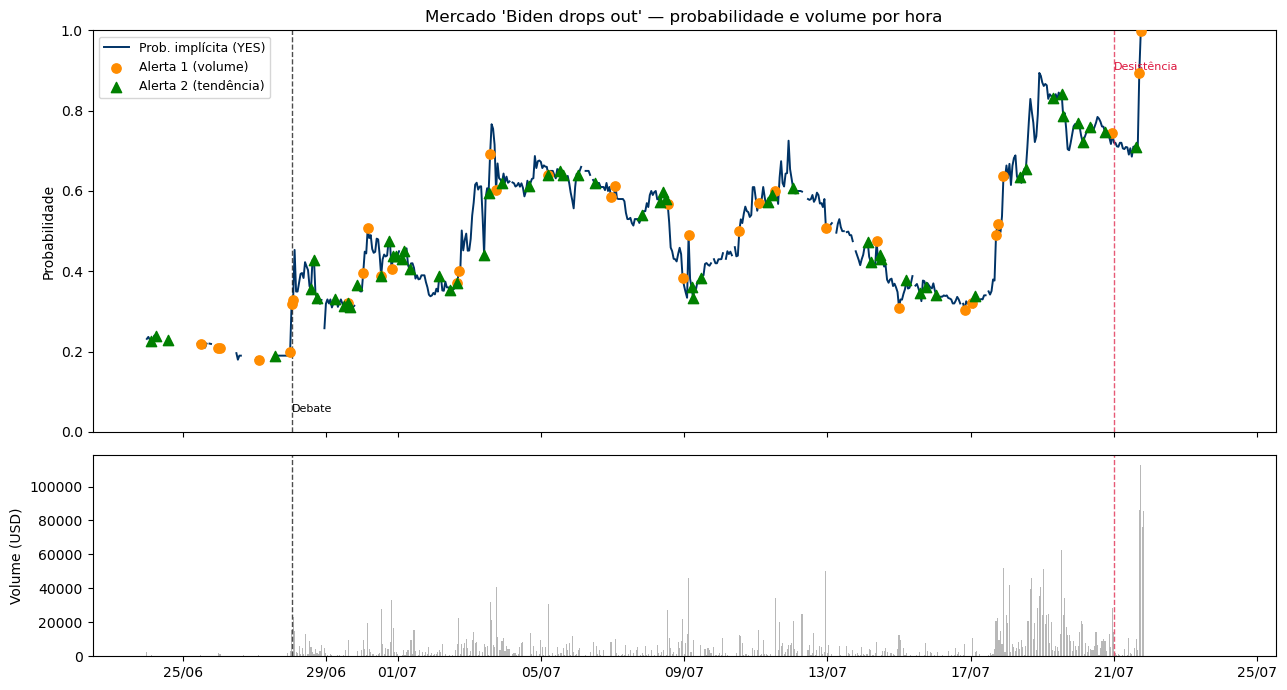

In [22]:
fig,(ax_p,ax_v)=plt.subplots(2,1,figsize=(13,7),sharex=True,gridspec_kw={"height_ratios":[2,1]})
ax_p.plot(feat["bucket_ts"], feat["vwap"], color="#003366", lw=1.4, label="Prob. implícita (YES)")
ax_p.set_ylabel("Probabilidade"); ax_p.set_ylim(0,1)
ax_p.set_title("Mercado 'Biden drops out' — probabilidade e volume por hora")
ax_v.bar(feat["bucket_ts"], feat["volume_usd"], width=0.03, color="#b8b8b8")
ax_v.set_ylabel("Volume (USD)")
for ax in (ax_p,ax_v):
    ax.axvline(DEBATE,color="black",ls="--",lw=1,alpha=.7)
    ax.axvline(WITHDRAW,color="crimson",ls="--",lw=1,alpha=.7)
idx = feat.set_index("bucket_ts")
ax_p.scatter(alerta1["data_referencia"], idx.loc[alerta1["data_referencia"],"vwap"],
             marker="o", s=45, color="darkorange", zorder=5, label="Alerta 1 (volume)")
ax_p.scatter(alerta2["data_referencia"], idx.loc[alerta2["data_referencia"],"vwap"],
             marker="^", s=55, color="green", zorder=5, label="Alerta 2 (tendência)")
ax_p.legend(loc="upper left", fontsize=9)
ax_p.annotate("Debate", xy=(DEBATE,0.05), fontsize=8)
ax_p.annotate("Desistência", xy=(WITHDRAW,0.9), fontsize=8, color="crimson")
ax_v.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m"))
plt.tight_layout(); plt.show()

## 6. Observações, hipóteses e limitações

### Observações (o que os dados mostram)
- A janela analisada (24/06–24/07, 721 horas) confirma que o mercado precificou a saída de Biden de forma **concentrada em poucos momentos**, e não como uma subida suave e contínua. A probabilidade implícita do YES partiu de ~0,18 antes do debate e terminou em ~0,999 em 21/07, mas o movimento se deu em degraus alinhados a eventos externos, não em rampa.

**O debate (27/06, 21h ET = 28/06 01h UTC) aparece com nitidez.** A primeira hora após o debate concentra o maior choque de volume relativo de toda a série: z-score de **21,1**, com o preço saltando de 0,20 para 0,32 em uma única hora e a participação subindo para 23 traders distintos (e 41 na hora seguinte). É o disparo mais forte do Alerta 1 fora da resolução — o catalisador agendado produziu reação imediata de preço *e* de fluxo.

**A resolução (21/07) é o pico absoluto de volume.** As duas horas finais do anúncio movimentaram US$ 86 mil e US$ 113 mil (a maior hora da janela inteira), com 82 e 110 traders distintos e o preço fechando em ~1,0. Coerente com a hipótese: o maior volume do período coincide com o desfecho, quando a incerteza colapsa.

**Entre os dois eventos, houve deriva com múltiplos saltos.** O Alerta 2 (cruzamento de médias) disparou 60 vezes ao longo do mês, acompanhando as sucessivas reprecificações da probabilidade entre ~0,3 e ~0,7 — a fase de pressão política que antecedeu a decisão. Os dois alertas, portanto, capturaram fenômenos distintos, como pretendido: o Alerta 1 marcou os **choques pontuais** (debate, dias de notícia, resolução), e o Alerta 2 mapeou as **mudanças de tendência** ao longo do processo.

### 6.2 Assertividade dos alertas

Definindo "movimento relevante" como um retorno de preço ≥ 5% em módulo nas 3 horas seguintes ao disparo:

| Alerta | Disparos | Precisão | Leitura |
|---|---|---|---|
| 1 — Volume (z-score) | 36 | **65,6%** | Dois em cada três picos de volume anômalo foram seguidos de movimento real de preço. |
| 2 — Tendência (cruzamento MM) | 60 | **40,4%** | Mais sensível e mais frequente; parte dos cruzamentos ocorre em regiões laterais, gerando sinais que não se confirmam. |

O contraste é esperado e informativo: o Alerta 1 é **mais seletivo** (exige anomalia de volume *e* participação distribuída), o que eleva a precisão ao custo de disparar menos; o Alerta 2 é **mais sensível**, capturando cada inflexão da média curta, o que aumenta a cobertura da deriva mas inclui mais falsos positivos em períodos de lateralização. Nenhum é "melhor" em absoluto — eles respondem a perguntas diferentes.


### Interpretação (hipóteses, sem afirmar causalidade)
- Os dados são **consistentes** com a hipótese inicial: o mercado reagiu de forma concentrada, com o volume anômalo tendendo a **coincidir ou anteceder** os saltos de probabilidade (visível nos disparos do Alerta 1 que precedem as subidas de 28/06, 03/07 e 17/07). Isso *sugere* que o fluxo de negociação carregava informação, mas não prova causalidade: a mesma correlação temporal seria produzida por participantes reagindo simultaneamente a notícias externas. A análise identifica **quando** o mercado se moveu, não **por que** cada movimento ocorreu.

### Limitações
- **Natureza observacional.** A coincidência temporal entre disparos e eventos externos não estabelece causalidade; participantes podem estar reagindo à mesma notícia que move o preço.
- **Disponibilidade ≠ ocorrência.** Sem `ingestion_timestamp` no dataset, assume-se `trade_timestamp` como o instante em que a informação estava disponível; atrasos de coleta não são observáveis e poderiam deslocar disparos próximos aos limites de hora.
- **Convergência terminal.** Perto de 21/07 o preço vai a ~1,0 de forma parcialmente mecânica (o evento tornou-se certo), e a soma YES+NO se descola de 1 (chega a 1,21 no dia). Os disparos de volume nessa janela refletem tanto informação nova quanto o encerramento das posições — a distinção entre os dois não é separável apenas com estes dados.
- **Suposição do z-score.** O baseline causal de 24h assume volume relativamente estável; após um choque, a variância recente infla e pode suprimir disparos legítimos nas horas seguintes (efeito visível na queda de sensibilidade logo após 28/06).
- **Assertividade dependente do critério.** O limiar de 5%/3h é uma escolha; limiares mais frouxos elevariam a precisão aparente de ambos os alertas, e mais rígidos a reduziriam. A métrica avalia consistência interna, não desempenho preditivo out-of-sample.
- **Métrica de avaliação é um *label*.** O retorno futuro de 3h serve apenas para *avaliar* os disparos; ele não entra em nenhuma feature que os gera. Manter essa separação é o que evita *data leakage* na análise.